# Bank Marketing Campaign Analytics

In [195]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Data Loading

In [3]:
df = pd.read_csv(r"C:\Users\dhami\Downloads\archive (11)\train.csv",sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## Data Information Gathering

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.shape

(45211, 17)

In [6]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [7]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [8]:
df.min(numeric_only=True)

age           18
balance    -8019
day            1
duration       0
campaign       1
pdays         -1
previous       0
dtype: int64

In [9]:
df.max(numeric_only=True)

age             95
balance     102127
day             31
duration      4918
campaign        63
pdays          871
previous       275
dtype: int64

In [10]:
df.mean(numeric_only=True)

age           40.936210
balance     1362.272058
day           15.806419
duration     258.163080
campaign       2.763841
pdays         40.197828
previous       0.580323
dtype: float64

In [11]:
df.median(numeric_only=True)

age          39.0
balance     448.0
day          16.0
duration    180.0
campaign      2.0
pdays        -1.0
previous      0.0
dtype: float64

In [12]:
df.count(numeric_only=True)

age         45211
balance     45211
day         45211
duration    45211
campaign    45211
pdays       45211
previous    45211
dtype: int64

In [13]:
df.std(numeric_only=True)

age           10.618762
balance     3044.765829
day            8.322476
duration     257.527812
campaign       3.098021
pdays        100.128746
previous       2.303441
dtype: float64

In [14]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Data Cleaning

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [17]:
df.rename(columns={'y':'subscription_status','pdays':'previous_days','poutcome':'previous_outcome'}, inplace=True)
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous_days,previous,previous_outcome,subscription_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [22]:
df['subscription_status']=df['subscription_status'].map({"no":0,"yes":1})
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous_days,previous,previous_outcome,subscription_status
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,1
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,1
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,1
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,0


In [158]:
lb=LabelEncoder()
df['job']=lb.fit_transform(df['job'])
df['marital']=lb.fit_transform(df['marital'])
df['education']=lb.fit_transform(df['education'])
df['default']=lb.fit_transform(df['default'])
df['housing']=lb.fit_transform(df['housing'])
df['loan']=lb.fit_transform(df['loan'])
df['contact']=lb.fit_transform(df['contact'])
df['previous_outcome']=lb.fit_transform(df['previous_outcome'])
df['month']=lb.fit_transform(df['month'])

In [159]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous_days,previous,previous_outcome,subscription_status
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3,0
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3,0
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3,0
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3,0
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,9,1,2,0,825,0,0,0,17,9,977,3,-1,0,3,1
45207,71,5,0,0,0,1729,0,0,0,17,9,456,2,-1,0,3,1
45208,72,5,1,1,0,5715,0,0,0,17,9,1127,5,184,3,2,1
45209,57,1,1,1,0,668,0,0,1,17,9,508,4,-1,0,3,0


## Logistic Regression

In [160]:
x=df.drop('subscription_status',axis=1)
y=df['subscription_status']

In [165]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20, random_state=42)

In [166]:
x_train

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous_days,previous,previous_outcome
3344,41,1,1,0,0,849,1,0,2,15,8,72,1,-1,0,3
17965,49,9,1,0,0,1415,1,0,0,30,5,269,2,-1,0,3
18299,42,0,1,1,0,3842,0,0,0,31,5,130,4,-1,0,3
10221,37,4,2,2,0,-119,1,0,2,11,6,375,11,-1,0,3
32192,56,1,1,0,0,3498,0,0,0,15,0,264,2,-1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,44,3,2,0,0,1059,0,0,2,18,6,2093,1,-1,0,3
44732,23,8,2,2,0,508,0,0,0,8,11,210,1,92,1,0
38158,34,9,0,2,0,1317,1,0,0,15,8,239,1,-1,0,3
860,33,5,1,1,0,165,0,0,2,7,8,111,1,-1,0,3


In [167]:
x_test

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,previous_days,previous,previous_outcome
3776,40,1,1,1,0,580,1,0,2,16,8,192,1,-1,0,3
9928,47,7,2,1,0,3644,0,0,2,9,6,83,2,-1,0,3
33409,25,8,2,2,0,538,1,0,0,20,0,226,1,-1,0,3
31885,42,4,1,2,0,1773,0,0,0,9,0,311,1,336,1,0
15738,56,4,1,2,0,217,0,1,0,21,5,121,2,-1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13353,47,4,1,2,0,1890,0,0,0,8,5,161,1,-1,0,3
38732,32,1,2,1,0,217,1,0,0,15,8,692,3,-1,0,3
5654,52,0,0,1,0,0,1,0,2,26,8,206,1,-1,0,3
3779,40,0,0,1,0,783,1,1,2,16,8,171,2,-1,0,3


In [168]:
y_train

3344     0
17965    0
18299    0
10221    0
32192    1
        ..
11284    1
44732    0
38158    0
860      0
15795    0
Name: subscription_status, Length: 36168, dtype: int64

In [180]:
y_test

3776     0
9928     0
33409    0
31885    0
15738    0
        ..
13353    0
38732    1
5654     0
3779     0
11677    0
Name: subscription_status, Length: 9043, dtype: int64

In [187]:
classifier = LogisticRegression()

In [188]:
classifier.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [189]:
y_pred=classifier.predict(x_test)

In [190]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(9043,))

In [191]:
print(accuracy_score(y_pred,y_test))

0.8878690699988941


In [192]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.98      0.90      0.94      8646
           1       0.22      0.60      0.32       397

    accuracy                           0.89      9043
   macro avg       0.60      0.75      0.63      9043
weighted avg       0.95      0.89      0.91      9043



In [193]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[7792  160]
 [ 854  237]]


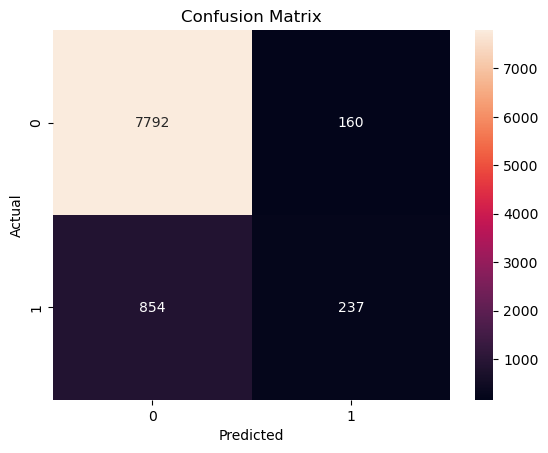

In [194]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()